# Библиотека Qiskit

In [1]:
!pip install qiskit ipywidgets

In [2]:
import qiskit

In [3]:
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister

In [4]:
from qiskit import execute, BasicAer

In [55]:
q = QuantumRegister(1)

In [56]:
c = ClassicalRegister(1)

In [57]:
circuit = QuantumCircuit(q, c)

In [58]:
circuit.x(q[0])

In [59]:
print(circuit)

     ┌───┐
q32: ┤ X ├
     └───┘
 c7: ═════
          


In [60]:
circuit.measure(q, c)

In [61]:
print(circuit)

     ┌───┐┌─┐
q32: ┤ X ├┤M├
     └───┘└╥┘
 c7: ══════╩═
             


In [62]:
backend = BasicAer.get_backend('qasm_simulator')

In [63]:
result = execute(circuit, backend, shots=100).result()

In [64]:
print(result.get_counts())

{'1': 100}


## 2 qubits

In [66]:
q = QuantumRegister(2)
c = ClassicalRegister(2)
circuit = QuantumCircuit(q, c)
circuit.h(q[0])

In [16]:
c = ClassicalRegister(2)

In [17]:
circuit = QuantumCircuit(q, c)

In [18]:
circuit.h(q[0])

In [67]:
circuit.cx(q[0], q[1])

In [68]:
print(circuit)

       ┌───┐     
q36_0: ┤ H ├──■──
       └───┘┌─┴─┐
q36_1: ─────┤ X ├
            └───┘
 c9_0: ══════════
                 
 c9_1: ══════════
                 


In [69]:
circuit.measure(q, c)

In [70]:
result = execute(circuit, backend, shots=10000).result()

In [71]:
print(result.get_counts())

{'11': 4934, '00': 5066}


In [34]:

backend=BasicAer.get_backend('qasm_simulator')

qreg_q = QuantumRegister(2, 'q')
creg_c = ClassicalRegister(2, 'c')
circuit = QuantumCircuit(qreg_q, creg_c)

circuit.h(qreg_q[0])
circuit.cx(qreg_q[0],qreg_q[1])
circuit.s(qreg_q[1])
circuit.h(qreg_q[1])
circuit.t(qreg_q[1])
circuit.h(qreg_q[1])
circuit.measure(qreg_q[0],creg_c[0])
result=execute(circuit,backend,shots=100).result()
circuit.measure(qreg_q[1],creg_c[1])
result=execute(circuit,backend,shots=100).result()
print(result.get_counts())

{'10': 62, '00': 38}


In [52]:
q = QuantumRegister(2)
c = ClassicalRegister(2)
circuit = QuantumCircuit(q, c)
circuit.h(qreg_q[0])

CircuitError: "Bit 'Qubit(QuantumRegister(2, 'q'), 0)' is not in the circuit."

In [42]:
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit
from qiskit import Aer, assemble
from qiskit.visualization import plot_histogram, plot_bloch_multivector, plot_state_qsphere, plot_state_city, plot_state_paulivec, plot_state_hinton

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')


# Define backend
sim = Aer.get_backend('aer_simulator')


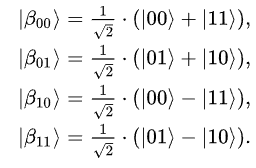

In [50]:
def createBellStates(inp1, inp2):
    qc = QuantumCircuit(2)
    qc.reset(range(2))

    if inp1=='1':
        qc.x(0)
    if inp2=='1':
        qc.x(1)

    qc.barrier()

    qc.h(0)
    qc.cx(0,1)

    qc.save_statevector()
    qobj = assemble(qc)
    result = sim.run(qobj).result()
    state = result.get_statevector()

    return qc, state, result

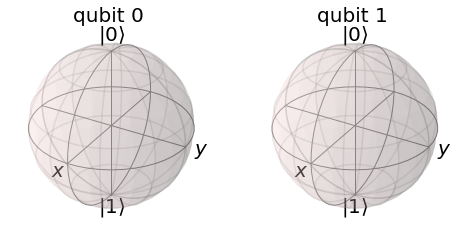

In [51]:
inp1 = 1
inp2 = 1

qc, state, result = createBellStates(inp1, inp2)

display(plot_bloch_multivector(state))